In [1]:
import os
import PyPDF2
import re
import pandas as pd

In [2]:
technology_infrastructure = {
    "AI Deployment": {
        "Systematic AI Integration": ["AI system", "artificial intelligence usage", "AI technology adoption", "AI system integration", "enterprise AI application", "AI infrastructure integration"],
        "Strategic AI Planning": ["AI strategic planning", "AI planning", "AI business strategy", "AI strategy", "AI roadmap", "AI roadmap development", "AI policy formulation"],
        "ML Algorithm Development & Implementation": ["machine learning", "ML algorithm", "ML algorithm", "machine learning model creation", "ML system design", "ML application development", "ML design"],
        "Deep Learning Application": ["deep learning", "neural networks", "complex algorithms", "deep learning application", "neural network solutions", "deep learning projects", "advanced neural computing"],
        "Neural Network Design & Application": ["neural networks", "neural network design", "neural network architecture", "neural system development", "computational neural networks"],
        "AI Operational Management": ["AI deployment management", "AI operational integration", "AI project execution", "AI technology management", "AI project", "AI Management"]
    },
    "IoT Utilization": {
        "IoT Network Deployment": ["IoT deployment", "IoT installation", "internet of things setup", "IoT platform integration", "smart system integration"],
        "IoT Systems Integration": ["IoT integration", "IoT-system integration", "IoT platform integration", "IoT platform"],
        "Smart Device Management": ["smart device", "connected device", "connected device control", "IoT device management", "smart technology administration", "IoT gadget operation"],
        "IoT Security Enhancement": ["IoT security protocols", "connected device protection", "IoT cybersecurity", "secure IoT networks"],
        "IoT Data Analytics": ["IoT data analysis", "connected device data processing", "IoT analytics", "smart device data insights"],
        "IoT Ecosystem Development": ["IoT ecosystem creation", "smart environment setup", "IoT network ecosystem", "connected system development"] #evtl raus wegen platfrom zweiter capab
    },
    "Blockchain Based Security Enhancement": {
        "Blockchain Infrastructure Implementation": ["blockchain", "blockchain infrastrcuture" , "lockchain implementation", "distributed ledger"],
        "Smart Contract Development": ["smart contracts", "smart contract design", "blockchain contract coding", "automated contract deployment", "smart legal agreements"],
        "Decentralized Security Solutions": ["decentralized security", "blockchain-based protection", "distributed security mechanisms", "distributed ledger security"],
        "Cryptographic Data Protection": ["blockchain data encryption", "cryptographic security protocols", "secure blockchain transactions"],
        "Blockchain Network Management": ["blockchain network oversight", "distributed ledger management", "blockchain control", "DLT management"],
        "Decentralization Strategy": ["decentralization planning", "blockchain strategy", "distributed systems strategy", "ledger strategy"]
    },
    "External Infrastructure Utilization": {
        "Cloud Computing Integration": ["cloud computing", "cloud services", "cloud technology", "cloud infrastructure", "cloud platforms"],
        "SaaS Solutions Adoption": ["SaaS", "software as a service", "cloud software", "service model", "application service"],
        "PaaS Systems Utilization": ["PaaS", "platform as a service", "development platform", "cloud platform", "service platform"],
        "IaaS Management": ["IaaS", "infrastructure as a service", "cloud infrastructure", "IT infrastructure", "resource management"],
        "Third-Party Cloud Services Utilization": ["cloud services", "online services", "web services", "cloud solutions", "internet services"],
        "External Infrastructure": ["external server infrastructure", "offsite resources", "third-party services", "external services", "computing resource outsourcing"],
        "Hybrid Cloud Strategies": ["hybrid cloud implementation", "mixed cloud", "integrated cloud systems", "hybrid cloud architecture"]
    },
    "Infrastructure Securitization": {
        "Cybersecurity Framework Implementation": ["cybersecurity system", "network protection", "data security", "threat prevention", "security management", "information protection strategy"],
        "Network Security Enhancement": ["network security", "firewall management", "intrusion detection", "network monitoring", "access control"],
        "Data Protection": ["data protection", "data encryption", "data privacy laws", "data privacy protection", "data confidentiality"],
        "Information Security Management": ["information security", "information risk assessment", "data security policy", "data compliance", "information security strategy"],
        "Data Encryption": ["data encryption", "encryption algorithms", "cryptography"],
        "Security Protocol Development": ["security protocols", "protocol design", "cybersecurity standards", "security framework", "security protocol implementation"]
    },
    "Structured Data Harvesting": {
        "Data Mining": ["data mining", "pattern recognition", "data extraction", "knowledge discovery", "database analysis"],
        "Big Data Analysis": ["big data analysis", "data analytics", "large-scale analysis", "predictive analytics"],
        "Data Analytics": ["data analytics", "statistical analysis", "business intelligence", "analytical tools", "data visualization", "information reporting systems", "data visualization techniques"],
        "Data Storage Optimization": ["structured data", "data organization", "database management", "data processing", "data repository management"],
        "Automated Data Collection": ["data harvesting", "web scraping", "data collection", "information gathering", "data extraction"],
        "Data Processing": ["data processing", "data manipulation", "information processing", "computational analysis", "data organization"]
    }
}
process_automation_optimization = {
    "Process Definition & Improvement": {
        "Process Mapping": ["process mapping", "workflow diagram", "process visualization", "process analysis", "workflow design"],
        "Process & Workflow Optimization": ["workflow optimization", "process efficiency", "workflow management", "process improvement", "efficiency enhancement", "business process optimization", "workflow efficiency improvements", "operational enhancement techniques"],
        "Lean Process Management": ["lean management", "lean principles", "process streamlining", "efficiency maximization", "lean methodology adoption", "lean process strategies"],
        "Business Process Redesign": ["process redesign", "workflow restructuring", "process reengineering", "business process redesign", "operational improvement", "business process reengineering", "process redesign strategies", "workflow redesign implementation"],
        "Continuous Process Improvement": ["continuous improvement", "kaizen", "process refinement", "ongoing optimization", "quality enhancement", "continuous improvement cycles", "Kaizen methodology", "ongoing process enhancements"],
        "Process Automation Integration": ["process automation integration", "process automation", "technology integration", "workflow automation", "automated solutions"],
        "Process Performance Monitoring": ["performance monitoring", "process tracking", "workflow analysis", "performance metrics", "process evaluation"]
    },
    "Process Standardization Establishment": {
        "Standardization Protocol Development": ["standardization protocols", "process standardization", "operational consistency", "operational standardization protocols"],
        "Uniformity Enforcement": ["uniformity enforcement", "consistency maintenance", "standard practices", "compliance management", "process uniformity"],
        "Operational Efficiency": ["operational efficiency", "efficiency improvement", "performance enhancement", "process optimization", "efficiency strategies"],
        "Process Documentation": ["process documentation", "workflow documentation", "procedure manuals", "standard operating procedures"],
        "Quality Control": ["quality control", "process quality", "quality assurance", "quality standards", "operational quality"],
        "Best Practices Implementation": ["best practices implementation", "industry standards", "benchmarking", "practice optimization", "operational excellence"],
        "Compliance and Regulatory Adherence": ["compliance monitoring", "regulatory compliance", "audit compliance", "compliance tracking", "legal adherence"]
    }
}

cybersecurity_governance = {
    "Data Management": {
        "Robust Data Governance": ["data governance frameworks", "data policy formulation", "data stewardship practices", "data governance", "information policy", "data strategy", "data stewardship", "data compliance"],
        "Lifecycle Data Management": ["data lifecycle planning", "data retention strategies", "information lifecycle management", "data lifecycle", "information lifecycle", "data retention", "data disposal", "data archiving"],
        "Secure Data Protocols": ["data security protocols", "encryption standard implementation", "data access controls", "security protocols", "data protection", "encryption standards", "access control", "security measures"],
        "Comprehensive Data Auditing": ["data audit procedures", "audit trail management", "data compliance checks", "data auditing", "audit trails", "compliance checks", "data verification", "audit reports"],
        "Information Architecture Optimization": ["information architecture design", "data structuring techniques", "system integration planning", "information architecture", "data structuring", "system design", "data integration"],
        "Access Control Systems": ["access management solutions", "authentication mechanisms", "authorization protocols", "access control", "authorization", "authentication", "user access", "security permissions"],
        "Data Backup and Recovery": ["data backup procedures", "data disaster recovery planning", "data replication techniques", "backup strategies", "data backup", "redundancy planning", "disaster recovery", "data replication"]
    },
    "Compliance Assurance": {
        "Regulatory Compliance Alignment": ["regulatory compliance strategies", "legal standards adherence", "regulatory framework application", "regulatory compliance", "legal standards", "industry regulations", "compliance alignment", "regulatory adherence"],
        "Compliance Training Programs": ["staff compliance training", "legal awareness sessions", "regulatory training modules", "compliance training", "staff education", "legal training", "policy training", "regulatory education"],
        "Policy and Legal Compliance Review": ["policy compliance checks", "legal review processes", "regulatory audit practices", "legal review", "compliance review", "legal assessment", "regulatory examination", "legal analysis"],
        "Effective Policy Implementation": ["compliance policy deployment", "policy enforcement mechanisms", "regulatory adherence measures", "policy implementation", "compliance policies", "policy enforcement", "regulatory policies", "policy management"],
        "Compliance Auditing and Monitoring": ["compliance audit techniques", "compliance tracking systems", "audit log maintenance", "audit trails", "audit logs", "compliance tracking", "record keeping", "transaction logging"],
        "Risk Assessment and Management": ["risk management frameworks", "risk mitigation strategies", "risk analysis methods", "risk management", "risk assessment", "risk mitigation", "risk analysis", "risk strategies"],
        "Standardized Compliance Reporting": ["compliance report generation", "regulatory reporting standards", "compliance documentation", "reporting standards", "compliance reporting", "regulatory reports", "standardized reporting"]
    },
    "Efficiency Auditing": {
        "Performance Efficiency Analysis": ["performance evaluation metrics", "efficiency analysis tools", "productivity assessment techniques", "performance analysis", "efficiency evaluation", "productivity assessment", "performance metrics", "operational analysis"],
        "Process and Workflow Evaluation": ["workflow efficiency audits", "process performance reviews", "operational evaluation systems", "process evaluation", "workflow analysis", "operational review", "process assessment", "efficiency review"],
        "Resource Utilization Review": ["resource allocation analysis", "asset utilization studies", "resource efficiency assessments", "resource utilization", "asset management", "resource efficiency", "usage analysis", "resource allocation"],
        "Technology and Auditing Tools": ["audit technology applications", "technology review practices", "audit tool utilization", "auditing technology", "audit tools", "technology review", "tech assessment", "audit software"],
        "Cost-Benefit and ROI Analysis": ["financial performance analysis", "cost-benefit assessments", "ROI calculation methods", "cost-benefit analysis", "financial assessment", "cost analysis", "benefit evaluation", "ROI analysis"],
        "Operational Review and Inspection": ["operational review processes", "audit inspection techniques", "efficiency inspection strategies", "operational review", "operational audit", "process inspection", "operational efficiency", "operational performance"],
        "Benchmarking and Best Practices": ["performance benchmarking methods", "industry standards analysis", "best practice identification", "benchmarking", "performance benchmarking", "industry standards", "comparative analysis", "best practice comparison"]
    },
    "Data Integrity": {
        "Data Integrity Assurance": ["data accuracy checks", "integrity testing methods", "data validation protocols", "integrity checks", "data verification", "accuracy testing", "consistency review", "validation checks"],
        "Error Detection and Correction": ["error detection mechanisms", "data quality improvement", "error correction processes", "error detection", "data quality", "anomaly detection", "error identification", "data correction"],
        "Consistency and Standardization": ["data consistency maintenance", "data standardization efforts", "synchronization techniques", "consistency maintenance", "data uniformity", "standardization", "synchronization", "data alignment"],
        "Data Quality Metrics and Indicators": ["quality measurement standards", "data quality metrics", "performance indicator systems", "quality metrics", "quality standards", "performance indicators", "quality measurement", "quality indicators"],
        "Data Integrity Policy and Standards": ["data integrity guidelines", "data policy formulation", "quality control standards", "integrity standards", "data principles", "quality guidelines", "data criteria", "standard practices"],
        "Comprehensive Data Cleansing": ["data cleaning processes", "data purification methods", "data sanitization techniques", "data cleansing", "data cleaning", "data purification", "data scrubbing", "data sanitization"]
    },
    "Reputation Safeguarding": {
        "Brand and Reputation Monitoring": ["brand reputation analysis", "online reputation tracking", "public perception monitoring", "brand monitoring", "reputation tracking", "brand reputation", "online monitoring", "public perception"],
        "Crisis Management and Response": ["crisis response planning", "emergency management strategies", "reputation recovery actions", "crisis management", "emergency response", "crisis response", "reputation recovery", "damage control"],
        "Public Relations and Image Management": ["PR management tactics", "media relations strategies", "public image enhancement", "public relations", "PR management", "media relations", "public image", "communications strategy"],
        "Customer Feedback and Insights": ["client feedback analysis", "customer satisfaction studies", "consumer opinion tracking", "customer feedback", "client reviews", "feedback analysis", "customer satisfaction", "consumer opinions"],
        "Digital Presence and Online Reputation": ["digital footprint management", "social media reputation", "online presence optimization", "online presence", "digital footprint", "social media presence", "web reputation", "online image"],
        "Strategic Reputation Planning": ["reputation management strategies", "brand strategy development", "image management planning", "reputation strategy", "reputation planning", "brand strategy", "reputation management", "image strategy"],
        "Media Communication and Relations": ["media communication policies", "press relationship management", "public announcement strategies", "media relations", "press management", "media strategy", "public announcements", "media engagement"]
    }
}

data_analytics = {
    "Decision Support": {
        "Advanced Decision Analytics": ["decision support", "analytics tools", "data-driven decisions", "business intelligence", "analytical insights", "decision support systems"],
        "Predictive Modelling Techniques": ["predictive analytics", "forecasting", "trend analysis", "predictive models", "data predictions"],
        "BI Solutions": ["business intelligence", "BI tools", "data analysis solutions", "performance metrics", "BI strategies"],
        "Strategic Planning Analytics": ["strategic analysis", "planning tools", "business strategy", "long-term planning", "strategy development"],
        "Analytics Reporting": ["reporting", "data reports", "analytics insights", "performance reporting", "data visualization"],
        "Decision Algorithms": ["algorithm design", "decision-making tools", "automated decision", "AI algorithms", "machine learning"],
        "Insight Visualization": ["data visualization", "charting", "graphical representation", "visualization tools", "data interpretation"]
    },
    "Process Transparency": {
        "Transparency Enhancement": ["process transparency", "openness", "transparency initiatives", "transparent operations", "clear processes"],
        "Visibility Analysis": ["process visibility", "workflow analysis", "operation monitoring", "visibility tools", "transparent reporting"],
        "Open Processes": ["open processes", "process accessibility", "process user involvement", "process stakeholder engagement", "open data"],
        "Process Documentation": ["process documentation", "record keeping", "process records", "workflow documentation", "operational documentation"],
        "Transparent Reporting": ["transparent reporting", "accountability", "clear communication", "open reporting", "stakeholder communication"],
        "Stakeholder Engagement": ["stakeholder involvement", "community engagement", "partner collaboration", "user feedback", "engagement strategies"],
        "Accountability Measures in Process Management": ["Process accountability", "process responsibility", "compliance checks", "auditing", "ethical standards", "process accountability measures", "compliance and ethics monitoring", "transparent management strategies"]
    },
    "Analytics Solutions": {
        "Comprehensive Data Analytics": ["data analysis solutions", "analytics solutions", "data mining", "statistical analysis", "business analytics", "data analytics techniques", "data pattern analysis", "business data processing"],
        "Innovative Analytics Implementation": ["advanced analytics solutions", "innovative data processing", "analytics technology application"],
        "Integrated Data Systems": ["data system integration", "centralized data management", "information consolidation methods", "data integration", "data consolidation"],
        "Analytics Solution Development": ["custom analytics solutions", "data solution engineering", "analytics system design"],
        "Automated Analytics Tools": ["analytics automation systems", "machine learning in analytics", "automated data insights", "analytics automation", "automated reporting"]
    }
}


digital_skills_training = {
    "Skills Acquisition Trainings": {
        "Digital Skill Development": ["skill building", "competency development", "personal development", "professional skills", "career growth"],
        "Training Programs": ["training sessions", "educational programs", "workshops", "skill courses", "learning modules"],
        "Learning and Development": ["continuous learning", "development opportunities", "education enhancement", "talent development", "professional growth"],
        "E-Learning Education": ["online learning", "digital courses", "virtual training", "web-based learning", "distance education"],
        "Workshop Development": ["interactive workshops", "training workshops", "educational seminars", "skill workshops", "professional workshops"],
        "Educational Initiatives": ["educational projects", "learning initiatives", "training campaigns", "development programs", "education strategies"],
        "Professional Growth Enhancement": ["career advancement", "career development", "professional progression", "skill enhancement", "growth opportunities"]
    },
    "Device Proficiency": {
        "Device Usage Training": ["technology operation", "equipment handling", "device management", "gadget proficiency", "hardware usage"],
        "Technology Proficiency": ["tech skills", "technology understanding", "IT skills", "digital proficiency", "technical knowledge"],
        "Hardware Skills Development": ["hardware operation", "equipment skills", "device expertise", "hardware management", "technical handling"],
        "User Training": ["user education", "technology training", "end-user training", "operational training", "skill instruction"],
        "Equipment Handling": ["equipment operation", "device handling", "technical usage", "machinery operation", "tool management"],
        "Technology Adaptation": ["tech adaptation", "technology adoption", "innovative technology", "tech integration"],
        "Operational Training": ["operational skills", "process training", "functional training", "system operation", "workflow training"]
    },
    "Technology Interaction": {
        "User Interface Design": ["UI design", "interface development", "user interaction", "screen layout", "UI optimization"],
        "Technology Interaction": ["tech engagement", "digital interaction", "user technology", "interactive technology", "tech usage"],
        "User Experience Design": ["UX enhancement", "user satisfaction", "experience design", "customer journey", "UX improvement"],
        "Interaction Technology Optimization": ["user engagement", "interaction improvement", "usability enhancement", "experience optimization", "interactive design", "interactive digital tools"],
        "User Engagement Development": ["engaging users", "audience interaction", "client engagement", "customer involvement", "user participation"],
    }
}

business_model_innovation = {
    "Core competency focus": {
        "Core Development": ["core business", "strategic focus", "core capabilities", "business strengths", "central competencies"],
        "Focus Strategy": ["strategic focus", "business prioritization", "core strategy", "focus areas", "strategic direction"],
        "Strength Identification": ["business strengths", "core busines strengths", "competitive advantage", "strength analysis", "key assets"],
        "Operational Core": ["core operations", "operational efficiency", "central processes", "main activities", "operational focus"],
        "Competency Prioritization": ["primary competencies", "skill focus", "key competencies", "talent development", "competency development"],
        "Core Enhancement": ["business core", "core improvement", "strengthening core", "business enhancement", "core development"],
        "Capability Focus": ["key capabilities", "capability development", "skill improvement", "core skills", "capability enhancement"]
    },
    "Outsourcing efficiency": {
        "Outsourcing Implementation": ["outsourcing", "external services", "contracting out", "service outsourcing", "business process outsourcing"],
        "BPO Strategy": ["business process outsourcing", "BPO", "outsourcing strategy", "operational outsourcing", "service delegation"],
        "Efficiency Optimization": ["cost efficiency", "operational efficiency", "process efficiency", "efficiency improvement", "resource optimization"],
        "Partnership Management": ["external partnerships", "collaborations", "strategic partnerships", "partner management", "alliances"],
        "Service Delegation": ["service outsourcing", "task delegation", "outsourced services", "external service providers", "service contracts"],
        "Operational Delegation": ["operational outsourcing", "process delegation", "external operations", "outsourcing operations", "operational efficiency"],
        "Strategic Delegation": ["strategic outsourcing", "strategic decisions", "outsourcing management", "strategic operations", "business strategy"]
    },
    "Revenue stream innovation": {
        "Model Innovation": ["business model development", "innovative business models", "business model innovation", "business model diversification"],
        "Revenue Development": ["revenue generation", "income streams", "financial growth", "revenue strategies", "profit maximization"],
        "Innovative Models": ["innovative revenue", "new business models", "innovation strategies", "revenue innovation", "creative solutions"],
        "Diversification Strategies": ["revenue diversification", "market expansion", "new markets", "diversified income", "business expansion"],
        "New Revenue Streams": ["new revenue streams", "alternative income", "emerging markets", "novel revenue sources", "revenue opportunities"],
        "Strategy Development": ["revenue strategies", "strategic planning", "financial planning", "business strategies", "market strategies"],
        "Monetization Strategies": ["monetization methods", "revenue models", "profit strategies", "earning mechanisms", "financial models"]
    },
    "Ecosystem creation": {
        "Ecosystem Building": ["business ecosystem", "ecosystem development", "collaborative networks", "business environment", "ecosystem strategy"],
        "Network Partnerships": ["partnership networks", "business networks", "collaborative partnerships", "network building", "strategic alliances"],
        "Collaboration Cultivation": ["collaborative environment", "partnership cultivation", "network collaboration", "teamwork", "joint ventures"],
        "Ecosystem Growth": ["ecosystem expansion", "network growth", "business development", "ecosystem enhancement", "market expansion"],
        "Building Networks": ["network building", "business networking", "community development", "network expansion", "relationship building"],
        "Strategic Collaboration": ["collaboration strategies", "partnership strategies", "collaborative efforts", "joint strategies", "cooperative planning"],
        "Integration Strategies": ["ecosystem integration", "system integration", "network integration", "business alignment", "strategic integration"]
    }
}
customer_experience = {
    "Customer need alignment": {
        "Needs Identification": ["customer needs", "market analysis", "client requirements", "user preferences", "demand assessment"],
        "Market Demand Analysis": ["market demands", "customer research", "trend analysis", "consumer behavior", "market insights"],
        "Customer Preference Assessment": ["consumer preferences", "customer likes", "preference research", "user interests", "client choices"],
        "Customer Insight Gathering": ["customer insights", "feedback analysis", "market intelligence", "client observations", "user understanding"],
        "Needs Analysis": ["need assessment", "requirement analysis", "demand forecasting", "market evaluation", "customer surveys"],
        "Customer Requirement Mapping": ["client requirements", "needs mapping", "service alignment", "customer expectations", "requirement understanding"],
        "Market Adaptation": ["market alignment", "market adaptation", "customer trends", "market adaptation strategies", "market changes"]
    },
    "Service innovation": {
        "Service Design Innovation": ["service design", "creative solutions", "innovative services", "design thinking", "service development"],
        "Service Creativity": ["innovative services", "creative offerings", "new service ideas", "service invention", "unique services"],
        "Service Delivery Optimization": ["service delivery", "delivery improvements", "efficiency enhancement", "service process", "delivery methods"],
        "Customer-Centric Solutions": ["customer-centric services", "client focus", "user-oriented services", "customer focus", "personalized services"],
        "Service Model Redefinition": ["service model innovation", "business model change", "service reimagining", "model transformation", "service redesign"],
        "Service Improvement": ["service enhancements", "quality improvement", "service upgrades", "enhancement strategies", "service refinement"],
        "Service Value Addition": ["value-added services", "additional benefits", "extra features", "added value", "supplementary services"]
    }
}
digital_leadership_culture = {
    "Strategy/Culture Alignment": {
        "Strategic Alignment": ["strategic alignment", "business strategy", "culture integration", "organizational alignment", "strategy culture fit"],
        "Culture Modification": ["culture change", "organizational culture", "cultural transformation", "culture shift", "cultural change"],
        "Strategy Development": ["organizational strategy", "strategic planning", "strategy formulation", "business planning", "strategic goals"],
        "Integration of Culture": ["cultural integration", "culture embedding", "values alignment", "cultural assimilation", "organizational values"],
        "Implementing Strategies": ["strategy implementation", "executing plans", "strategy execution", "action plans", "strategic initiatives"],
        "Transforming Culture": ["cultural transformation", "culture development", "changing culture", "culture renewal", "organizational change"],
        "Process Alignment": ["alignment processes", "process harmonization", "workflow alignment", "operational alignment", "procedure alignment"]
    },
    "Leadership-Driven Change": {
        "Leadership Development": ["leadership training", "leadership skills", "executive development", "leadership growth", "management training"],
        "Managing Change": ["change management", "transition management", "organizational change", "change initiatives", "change strategies"],
        "Strategic Guidance": ["strategic leadership", "leadership direction", "visionary leadership", "strategic vision", "leadership influence"],
        "Role Definition": ["leadership roles", "role clarification", "role responsibilities", "executive roles", "management roles"],
        "Initiative Leadership": ["change initiatives", "project leadership", "initiative management", "program leadership", "project direction"],
        "Change Leadership": ["leadership in change", "change champions", "leading transformation", "change facilitation", "transformation leadership"],
        "Transformational Guidance": ["transformation leadership", "guiding change", "transformation strategy", "change guidance", "leading innovation"]
    },
    "Digital Proficiency Enhancement": {
        "Digital Literacy": ["digital literacy", "technology understanding", "digital skills", "tech savvy", "digital knowledge"],
        "Skill Development": ["digital skills training", "tech skills development", "skill improvement", "competency development", "professional training"],
        "Adopting Technology": ["technology adoption", "tech integration", "digital integration", "technology assimilation"],
        "Training Programs": ["digital training", "technology education", "online courses", "e-learning programs", "training workshops"],
        "Tech Proficiency": ["technological proficiency", "tech mastery", "IT skills", "technology expertise", "digital competence"],
        "Capability Building": ["digital capabilities", "skill building", "competence enhancement", "capability development", "talent growth"],
        "Enhancing Skills": ["skill enhancement", "professional growth", "skill advancement", "career development", "upskilling"]
    },
    "Change Management Excellence": {
        "Initiative Implementation": ["change initiatives", "project implementation", "initiative execution", "program rollout", "strategy deployment"],
        "Managing Transformation": ["transformation management", "change leadership", "organizational transformation", "change processes", "transition management"],
        "Strategy Execution": ["change strategy", "strategic execution", "implementation plan", "strategy realization", "executing strategy"],
        "Process Reengineering": ["change processes", "process improvement", "reengineering efforts", "workflow redesign", "process overhaul"],
        "Organizational Redesign": ["organizational change", "restructuring", "organizational redesign", "business transformation", "corporate reorganization"],
        "Adopting Changes": ["change adoption", "embracing change", "change acceptance", "adaptation to change", "accepting new processes"],
        "Leading Change": ["change leadership", "leading transformation", "change direction", "change management leadership", "guiding change"]
    },
    "Adaptability and Resilience": {
        "Adaptability Enhancement": ["organizational adaptability", "flexibility", "adaptive culture", "responsive organization", "change readiness"],
        "Organizational Resilience Development": ["business resilience", "organizational resilience", "resilience building", "crisis resilience", "sustainability"],
        "Flexibility Cultivation": ["flexibility", "agile practices", "flexible approaches", "adaptability", "agility"],
        "Strategy Adaptation Readiness": ["adaptive strategies", "strategy modification", "strategic flexibility", "changing strategies", "strategic adjustments"],
        "Agility Implementation": ["agile practices", "agility", "agile methodologies", "agile transformation", "business agility"],
        "Responsive Strategy Planning": ["responsive strategies", "quick response", "adaptive planning", "rapid adaptation", "flexible planning"]
    }
}



In [3]:
pillars_data = {
    "Technology & Infrastructure" : technology_infrastructure,
    "Process Automation & Optimization" : process_automation_optimization,
    "Cybersecurity & Governance" : cybersecurity_governance,
    "Data & Analytics" : data_analytics,
    "Digital Skills & Training" : digital_skills_training,
    "Business Model Innovation" : business_model_innovation,
    "Customer Experience" : customer_experience,
    "Digital Leadership & Culture" : digital_leadership_culture

}

In [4]:
def extract_relevant_text(file_path):
    with open(file_path, 'rb') as file:
        reader = PyPDF2.PdfReader(file)
        full_text = ""
        for page in reader.pages:
            full_text += page.extract_text() + "\n"
        return full_text

In [5]:
def search_keywords(text, keywords):
    counts = {keyword: len(re.findall(re.escape(keyword), text, re.IGNORECASE)) for keyword in keywords}
    return counts


In [6]:
folder_path = '/Users/maxbreitruck/Library/CloudStorage/OneDrive-UniversitätSt.Gallen/001_IWI/Dissertation/Paper#2/Eikon Daten' 
# Using a list to store data for DataFrame
data_for_df_atr = []

for filename in os.listdir(folder_path):
    if filename.endswith('.pdf'):
        file_path = os.path.join(folder_path, filename)
        text = extract_relevant_text(file_path)

        for pillar, capabilities in pillars_data.items():
            for capability, practices in capabilities.items():
                for practice, keywords in practices.items():
                    counts = search_keywords(text, keywords)
                    for keyword, count in counts.items():
                        data_for_df_atr.append({
                            "Filename": filename,
                            "Pillar": pillar,
                            "Capability": capability,
                            "Practice": practice,
                            "Keyword": keyword,
                            "Count": count
                        })

# Create DataFrame
df_results_abstract_to_references = pd.DataFrame(data_for_df_atr)

# Display DataFrame
df_results_abstract_to_references

,Filename,Pillar,Capability,Practice,Keyword,Count
0,Receipt Date - 2023-Aug-21 - UBSG.S - UBS Grou...,Technology & Infrastructure,AI Deployment,Systematic AI Integration,AI system,0
1,Receipt Date - 2023-Aug-21 - UBSG.S - UBS Grou...,Technology & Infrastructure,AI Deployment,Systematic AI Integration,artificial intelligence usage,0
2,Receipt Date - 2023-Aug-21 - UBSG.S - UBS Grou...,Technology & Infrastructure,AI Deployment,Systematic AI Integration,AI technology adoption,0
3,Receipt Date - 2023-Aug-21 - UBSG.S - UBS Grou...,Technology & Infrastructure,AI Deployment,Systematic AI Integration,AI system integration,0
4,Receipt Date - 2023-Aug-21 - UBSG.S - UBS Grou...,Technology & Infrastructure,AI Deployment,Systematic AI Integration,enterprise AI application,0
...,...,...,...,...,...,...
4399,Receipt Date - 2023-Feb-02 - ROG.S - Roche Hol...,Digital Leadership & Culture,Adaptability and Resilience,Responsive Strategy Planning,responsive strategies,0
4400,Receipt Date - 2023-Feb-02 - ROG.S - Roche Hol...,Digital Leadership & Culture,Adaptability and Resilience,Responsive Strategy Planning,quick response,0
4401,Receipt Date - 2023-Feb-02 - ROG.S - Roche Hol...,Digital Leadership & Culture,Adaptability and Resilience,Responsive Strategy Planning,adaptive planning,0
4402,Receipt Date - 2023-Feb-02 - ROG.S - Roche Hol...,Digital Leadership & Culture,Adaptability and Resilience,Responsive Strategy Planning,rapid adaptation,0


In [7]:
df_results_abstract_to_references.head(370)

,Filename,Pillar,Capability,Practice,Keyword,Count
0,Receipt Date - 2023-Aug-21 - UBSG.S - UBS Grou...,Technology & Infrastructure,AI Deployment,Systematic AI Integration,AI system,0
1,Receipt Date - 2023-Aug-21 - UBSG.S - UBS Grou...,Technology & Infrastructure,AI Deployment,Systematic AI Integration,artificial intelligence usage,0
2,Receipt Date - 2023-Aug-21 - UBSG.S - UBS Grou...,Technology & Infrastructure,AI Deployment,Systematic AI Integration,AI technology adoption,0
3,Receipt Date - 2023-Aug-21 - UBSG.S - UBS Grou...,Technology & Infrastructure,AI Deployment,Systematic AI Integration,AI system integration,0
4,Receipt Date - 2023-Aug-21 - UBSG.S - UBS Grou...,Technology & Infrastructure,AI Deployment,Systematic AI Integration,enterprise AI application,0
...,...,...,...,...,...,...
365,Receipt Date - 2023-Aug-21 - UBSG.S - UBS Grou...,Cybersecurity & Governance,Compliance Assurance,Standardized Compliance Reporting,compliance documentation,0
366,Receipt Date - 2023-Aug-21 - UBSG.S - UBS Grou...,Cybersecurity & Governance,Compliance Assurance,Standardized Compliance Reporting,reporting standards,20
367,Receipt Date - 2023-Aug-21 - UBSG.S - UBS Grou...,Cybersecurity & Governance,Compliance Assurance,Standardized Compliance Reporting,compliance reporting,0
368,Receipt Date - 2023-Aug-21 - UBSG.S - UBS Grou...,Cybersecurity & Governance,Compliance Assurance,Standardized Compliance Reporting,regulatory reports,0


In [8]:
grouped_by_pillars_atr = df_results_abstract_to_references.groupby(['Pillar', 'Capability', 'Practice', 'Keyword']).sum().reset_index()
grouped_by_pillars_atr.head(10)

,Pillar,Capability,Practice,Keyword,Count
0,Business Model Innovation,Core competency focus,Capability Focus,capability development,0
1,Business Model Innovation,Core competency focus,Capability Focus,capability enhancement,0
2,Business Model Innovation,Core competency focus,Capability Focus,core skills,0
3,Business Model Innovation,Core competency focus,Capability Focus,key capabilities,0
4,Business Model Innovation,Core competency focus,Capability Focus,skill improvement,0
5,Business Model Innovation,Core competency focus,Competency Prioritization,competency development,0
6,Business Model Innovation,Core competency focus,Competency Prioritization,key competencies,18
7,Business Model Innovation,Core competency focus,Competency Prioritization,primary competencies,0
8,Business Model Innovation,Core competency focus,Competency Prioritization,skill focus,0
9,Business Model Innovation,Core competency focus,Competency Prioritization,talent development,2


In [9]:
# Group the DataFrame by 'Practice' and count the unique filenames for each practice
practice_counts_atr = df_results_abstract_to_references.groupby('Practice')['Filename'].nunique().reset_index()

# Rename the columns for clarity
practice_counts_atr.columns = ['Practice', 'FileCount']

practice_counts_atr.head(-10)

,Practice,FileCount
0,AI Operational Management,4
1,Access Control Systems,4
2,Accountability Measures in Process Management,4
3,Adaptability Enhancement,4
4,Adopting Changes,4
...,...,...
181,Technology Proficiency,4
182,Technology and Auditing Tools,4
183,Third-Party Cloud Services Utilization,4
184,Training Programs,4


In [10]:
grouped_by_pillars_second_score_atr = df_results_abstract_to_references.groupby(['Pillar', 'Capability', 'Practice', 'Keyword']).sum().reset_index()

# Grouping again to sum the counts for each practice
grouped_by_practice_atr = grouped_by_pillars_second_score_atr.groupby(['Pillar', 'Capability', 'Practice']).agg({'Count': 'sum'}).reset_index()
grouped_by_practice_atr.head(50)

,Pillar,Capability,Practice,Count
0,Business Model Innovation,Core competency focus,Capability Focus,0
1,Business Model Innovation,Core competency focus,Competency Prioritization,20
2,Business Model Innovation,Core competency focus,Core Development,20
3,Business Model Innovation,Core competency focus,Core Enhancement,0
4,Business Model Innovation,Core competency focus,Focus Strategy,15
5,Business Model Innovation,Core competency focus,Operational Core,4
6,Business Model Innovation,Core competency focus,Strength Identification,5
7,Business Model Innovation,Ecosystem creation,Building Networks,0
8,Business Model Innovation,Ecosystem creation,Collaboration Cultivation,24
9,Business Model Innovation,Ecosystem creation,Ecosystem Building,130


In [11]:
practice_in_file = df_results_abstract_to_references[df_results_abstract_to_references['Count'] > 0].drop_duplicates(subset=['Filename', 'Practice'])

# Select only the relevant columns
practice_in_file = practice_in_file[['Filename', 'Practice']]

practice_in_file.head(10)

,Filename,Practice
13,Receipt Date - 2023-Aug-21 - UBSG.S - UBS Grou...,ML Algorithm Development & Implementation
64,Receipt Date - 2023-Aug-21 - UBSG.S - UBS Grou...,Blockchain Infrastructure Implementation
96,Receipt Date - 2023-Aug-21 - UBSG.S - UBS Grou...,SaaS Solutions Adoption
124,Receipt Date - 2023-Aug-21 - UBSG.S - UBS Grou...,Cybersecurity Framework Implementation
132,Receipt Date - 2023-Aug-21 - UBSG.S - UBS Grou...,Network Security Enhancement
133,Receipt Date - 2023-Aug-21 - UBSG.S - UBS Grou...,Data Protection
138,Receipt Date - 2023-Aug-21 - UBSG.S - UBS Grou...,Information Security Management
157,Receipt Date - 2023-Aug-21 - UBSG.S - UBS Grou...,Big Data Analysis
160,Receipt Date - 2023-Aug-21 - UBSG.S - UBS Grou...,Data Analytics
209,Receipt Date - 2023-Aug-21 - UBSG.S - UBS Grou...,Continuous Process Improvement


In [12]:
practice_count_per_file_atr = practice_in_file.groupby('Filename').count().reset_index()
practice_count_per_file_atr.rename(columns={'Practice': 'PracticeCount'}, inplace=True)

practice_count_per_file_atr.head(10)

,Filename,PracticeCount
0,Receipt Date - 2023-Aug-21 - UBSG.S - UBS Grou...,81
1,Receipt Date - 2023-Feb-01 - NOVN.S - Novartis...,47
2,Receipt Date - 2023-Feb-02 - ROG.S - Roche Hol...,41
3,Receipt Date - 2023-May-19 - NESN.S - Nestle S...,36


In [13]:
# Counting the number of files in which each practice appears
practice_count_across_files_atr = practice_in_file.groupby('Practice').nunique()['Filename'].reset_index()
practice_count_across_files_atr.rename(columns={'Filename': 'FileCount'}, inplace=True)

practice_count_across_files_atr.head(-50)

,Practice,FileCount
0,Access Control Systems,3
1,Accountability Measures in Process Management,3
2,Adaptability Enhancement,4
3,Advanced Decision Analytics,1
4,Agility Implementation,4
5,Analytics Reporting,4
6,Automated Data Collection,2
7,BI Solutions,1
8,Benchmarking and Best Practices,1
9,Best Practices Implementation,2


Pillar: Cybersecurity & Governance, Entries: 19


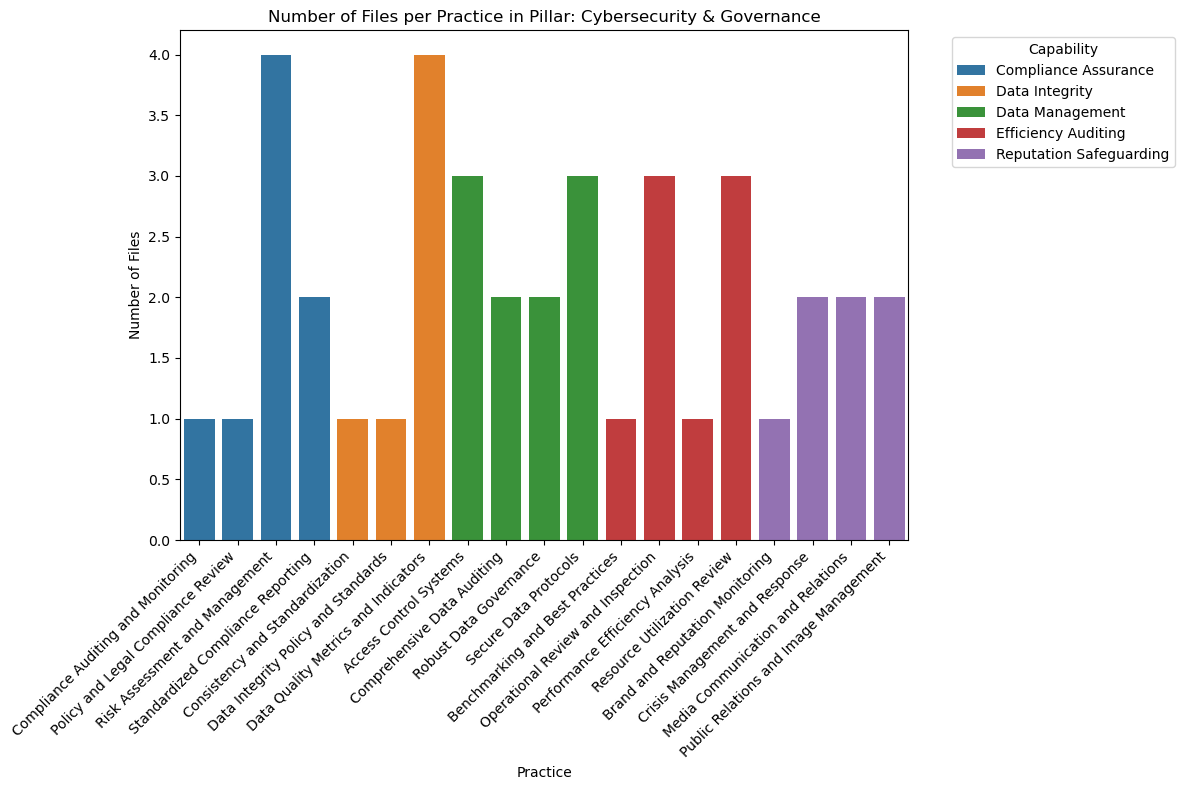

Pillar: Data & Analytics, Entries: 12


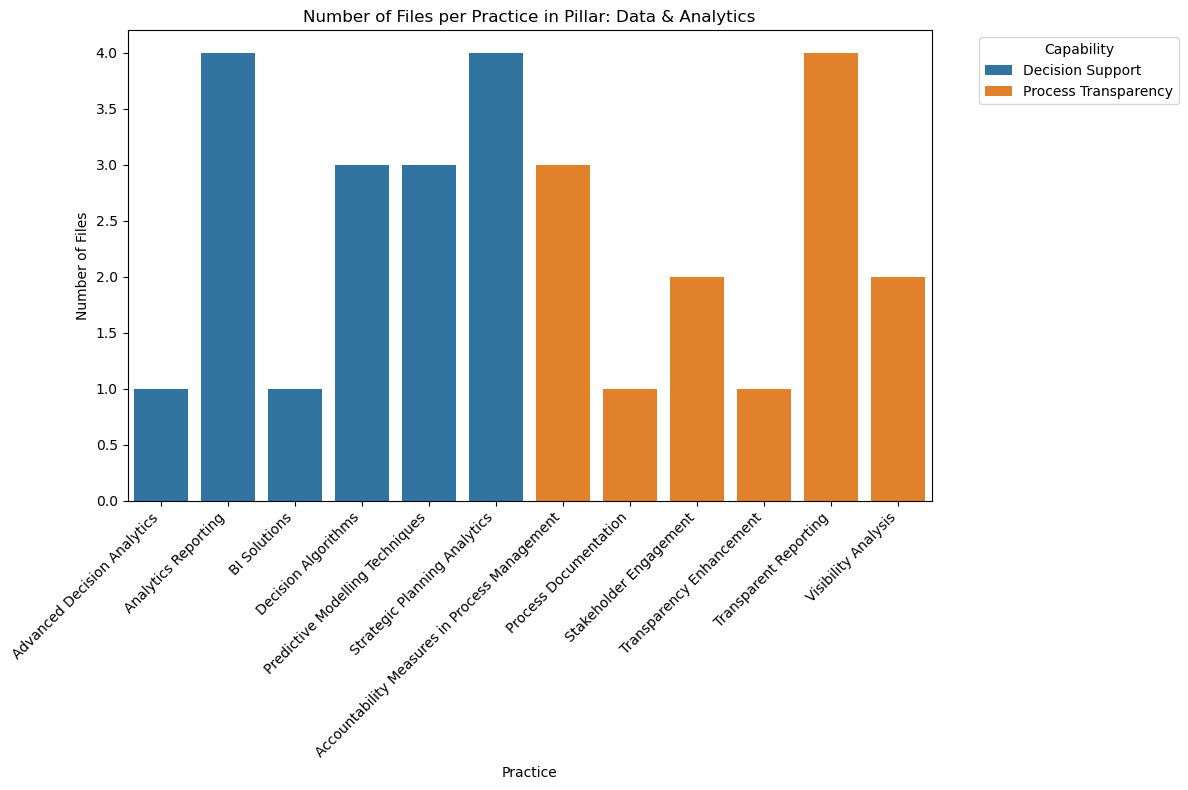

Pillar: Digital Leadership & Culture, Entries: 19


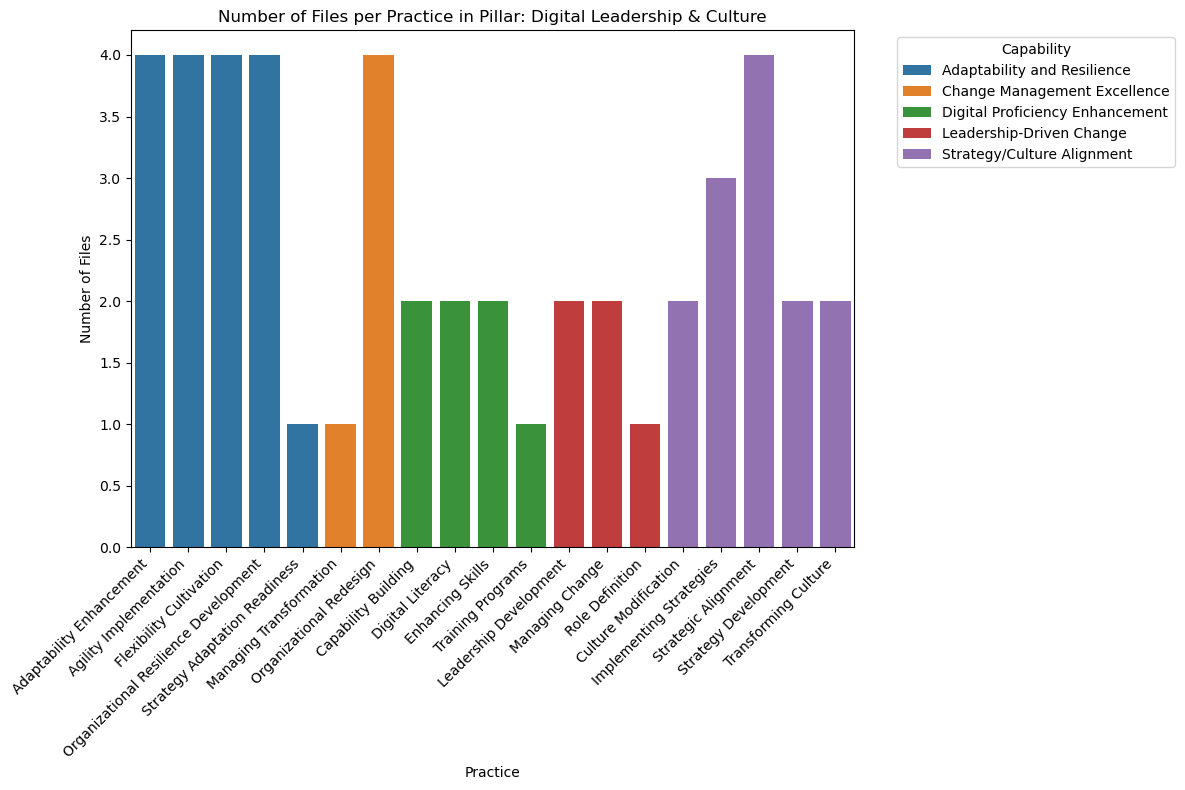

Pillar: Technology & Infrastructure, Entries: 11


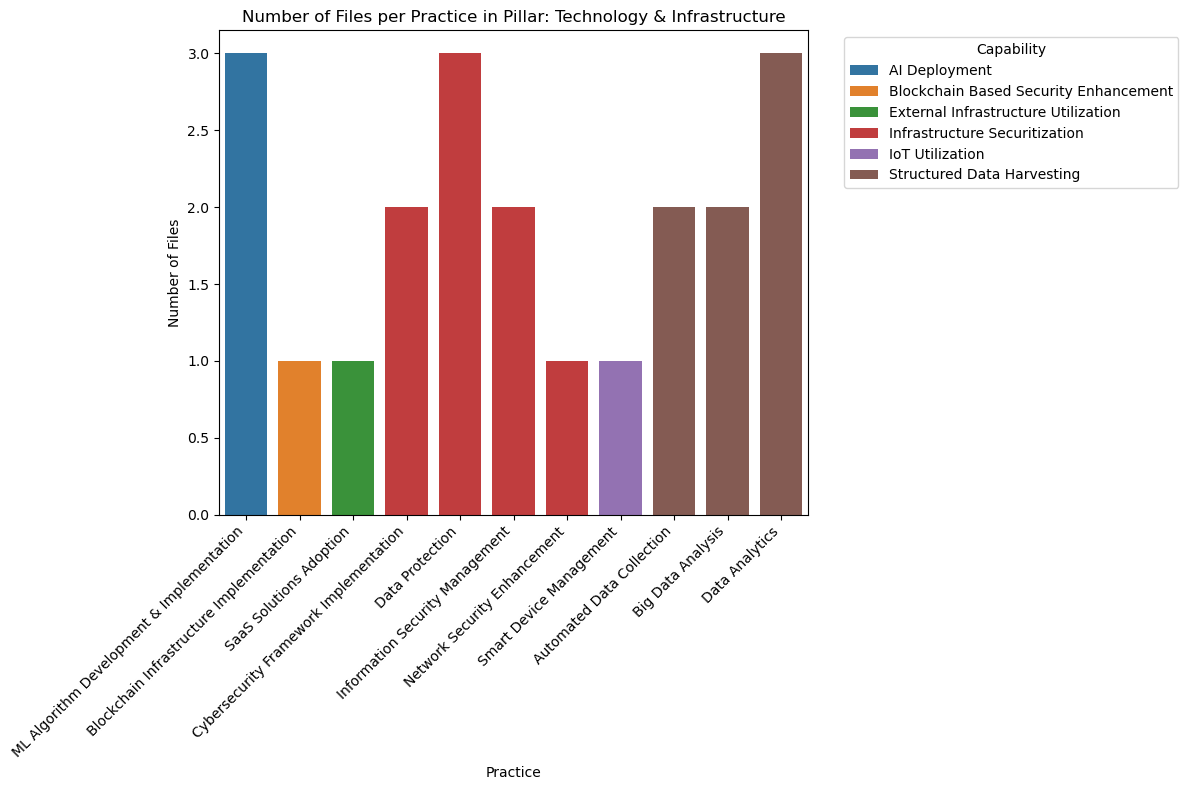

Pillar: Process Automation & Optimization, Entries: 7


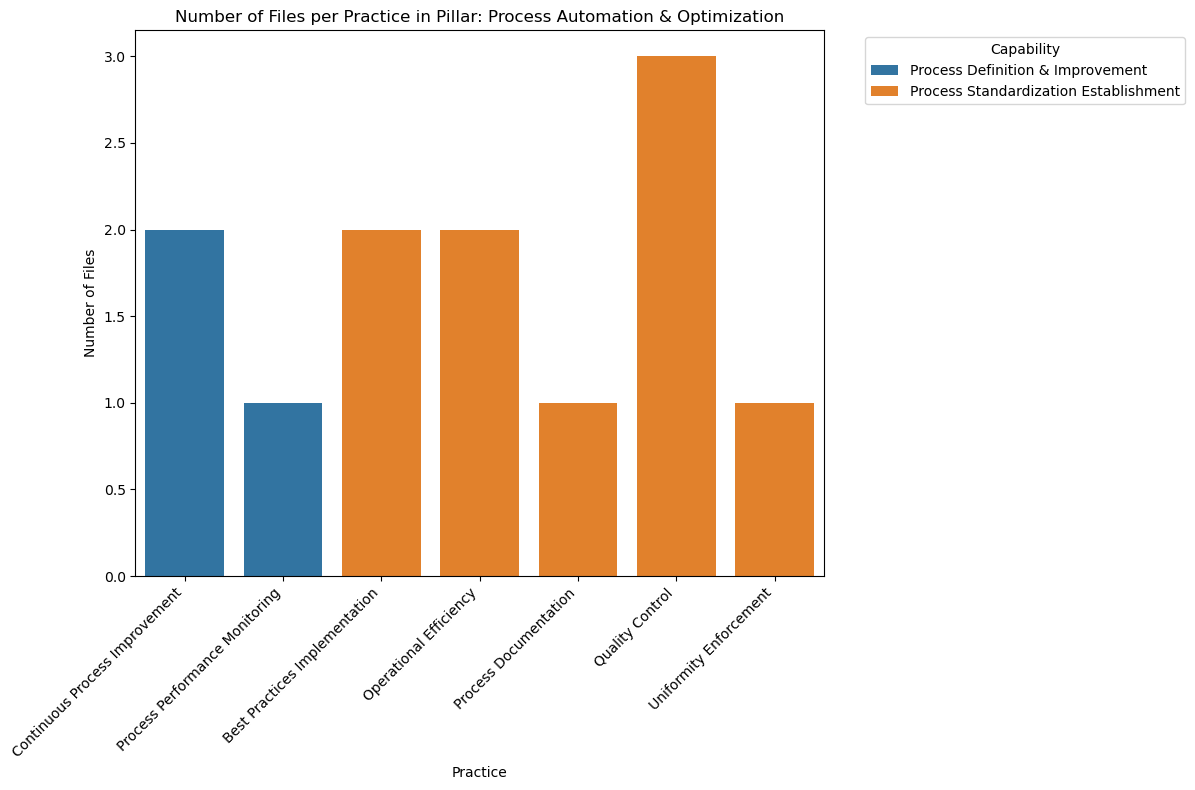

Pillar: Business Model Innovation, Entries: 20


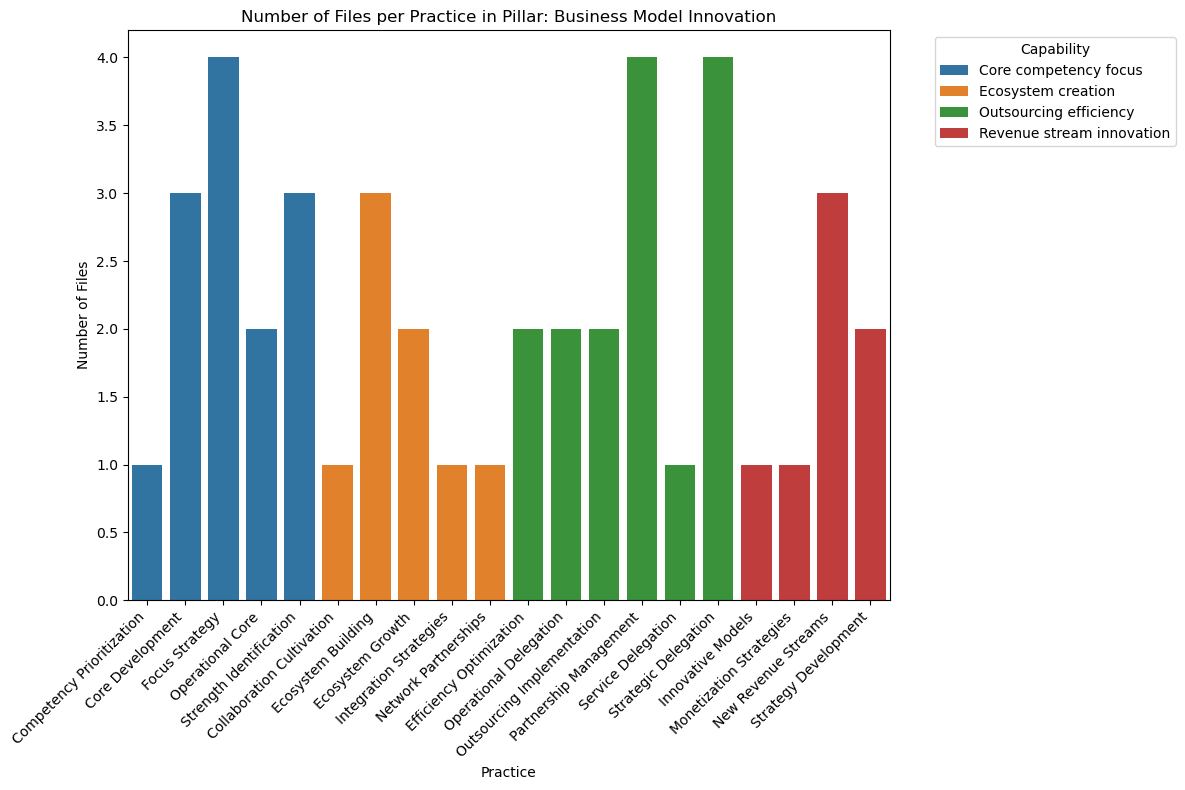

Pillar: Customer Experience, Entries: 7


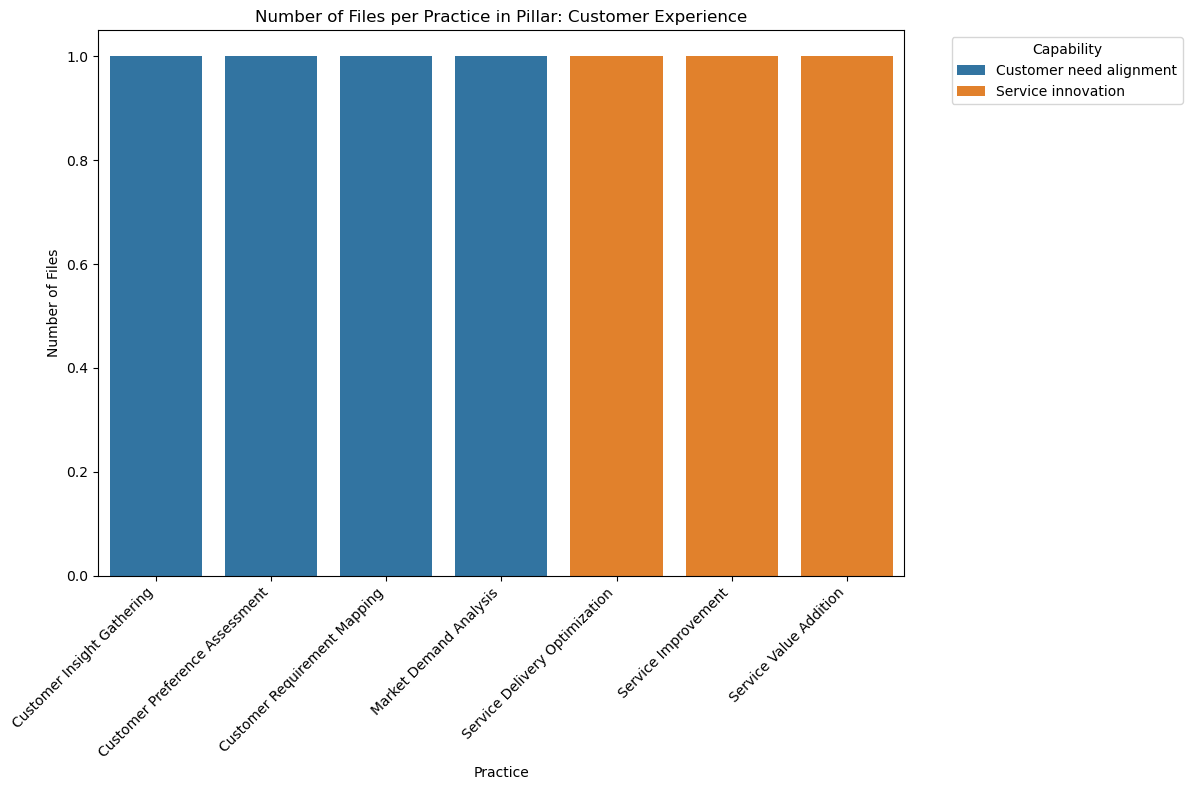

Pillar: Digital Skills & Training, Entries: 9


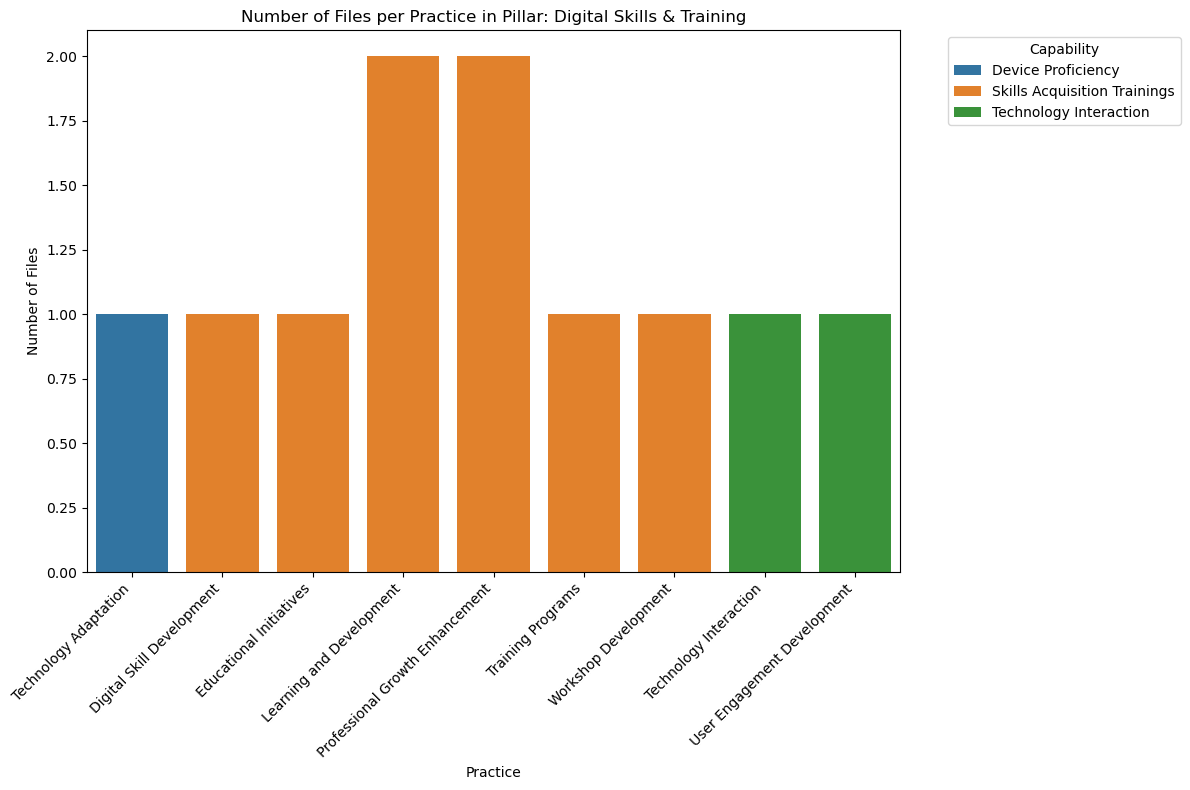

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# Merging the count data with the original DataFrame to get Pillar and Capability information for each Practice
merged_df = pd.merge(practice_count_across_files_atr, df_results_abstract_to_references[['Practice', 'Pillar', 'Capability']].drop_duplicates(), on='Practice')

# Getting unique list of pillars
pillars = merged_df['Pillar'].unique()

for pillar in pillars:
    subset = merged_df[merged_df['Pillar'] == pillar]
    print(f"Pillar: {pillar}, Entries: {len(subset)}")  # Print statement to check entries
    if not subset.empty:
        plt.figure(figsize=(12, 8))
        subset = subset.sort_values(by=['Capability', 'Practice'])
        sns.barplot(x='Practice', y='FileCount', hue='Capability', data=subset, dodge=False)
        plt.title(f'Number of Files per Practice in Pillar: {pillar}')
        plt.xlabel('Practice')
        plt.ylabel('Number of Files')
        plt.xticks(rotation=45, ha='right')
        plt.legend(title='Capability', bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.tight_layout()
        plt.show()